# Fully-connected neurale netwerken - Classification

In this notebook, we will learn how we can apply neural networks to classification problems. You've already seen how neural networks work and how they are trained. The biggest difference between regression- and classification applications is the choice of the loss function.

## 1 The MNIST dataset - the "Hello, world!" of neural network classification

### 1.1 The dataset

The MNIST-dataset is a well-known collection hand-written numbers that are used for machine learning and computer vision based research. It contains 70.000 grey images (1 color channel) of hand-written numbers, each with a format of 28x28 pixels. The numbers are labeled with the corresponding numeric values, from 0 to 9.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# Load the data using the Keras datasets API and split it between train and test sets
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 [==============================] - 0s 0us/step


### 1.2 Visualizing the dataset

1. What is the shape of the trainingsfeatures (X_train)? Wat does each dimension in the shape mean?
2. What is the shape of the trainingslabels (y_train)? What does each dimension the shape mean?
3. What are the min- and max-values of the training features? What do these values mean?

```YOUR ANSWERS HERE```

In de following cell, will we plot a random sample of the dataset. Execute it a couple of times to see random examples.

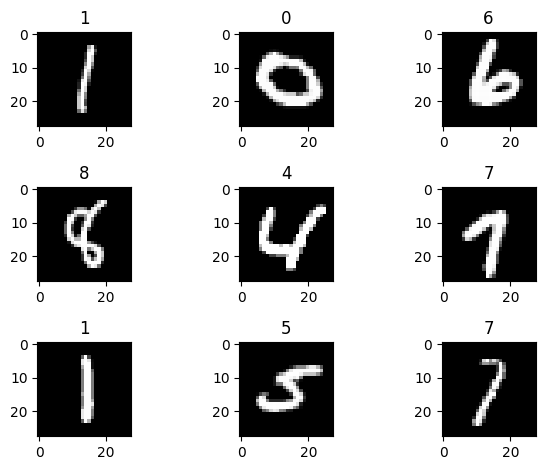

In [ ]:
# Plot a random sample from the dataset
indices = np.random.choice(len(x_train), size=9, replace=False)

for count, value in enumerate(indices):
    plt.subplot(3, 3, count+1)
    plt.imshow(x_train[value], cmap="gray")
    plt.title(y_train[value])

plt.tight_layout()
plt.show()

### 1.3 Building the neural network

There are a few things to take into account, while building the classification model:
1. The shape of the input data is two-dimensional. A "fully-connected" or "dense" neural network can only process one-dimensional data. So, we need to "flatten" the data in one dimension.
2. This is a classification problem with multiple possible labels. In this case, the right loss function we should use is the "categorical crossentropy loss".

Build the neural network in the following cell.

Compile the model with the right loss function, a suitable optimizer and a suitable metric.

### 1.4 Training the model

Train your model in the following code cell.

### 1.5 Visualizing the results

Plot the model-losscurves below.

Evaluate the model on the testset.

## 2 The Fashion MNIST dataset

Train a model to classify the Fashion MNIST-dataset. Follow the same steps as the MNIST-dataset.

In [ ]:
# Getting the data

fashion_mnist = tf.keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

4422102/4422102 [==============================] - 0s 0us/step


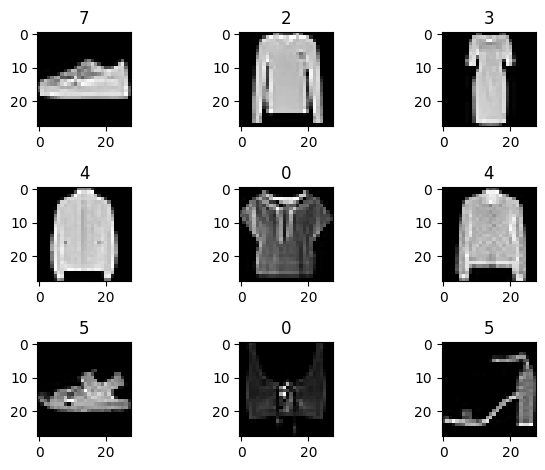

In [ ]:
# Plot a random sample from the dataset
indices = np.random.choice(len(train_images), size=9, replace=False)

for count, value in enumerate(indices):
    plt.subplot(3, 3, count+1)
    plt.imshow(train_images[value], cmap="gray")
    plt.title(train_labels[value])

plt.tight_layout()
plt.show()

## 3 TensorFlow Playground spirale dataset

Make a network to classify the spiral-formed dataset on [TensorFlow Playground](https://playground.tensorflow.org/) website te classificeren. Don't write code yet, just use the website.

Now, implement this network in TensorFlow-code. The dataset is provided to you.

<Axes: xlabel='x1', ylabel='x2'>

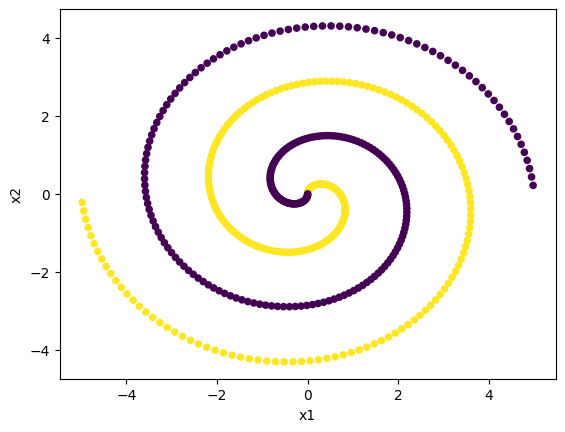

In [ ]:
import random
import math
from typing import List

class Example2D:
    def __init__(self, x: float, y: float, label: int):
        self.x = x
        self.y = y
        self.label = label

def classifySpiralData(numSamples: int, noise: float) -> List[Example2D]:
    points = []
    n = int(numSamples / 2)

    def genSpiral(deltaT: float, label: int) -> None:
        for i in range(n):
            r = i / n * 5
            t = 1.75 * i / n * 2 * 3.14159 + deltaT
            x = r * math.sin(t) + random.uniform(-1, 1) * noise
            y = r * math.cos(t) + random.uniform(-1, 1) * noise
            points.append(Example2D(x, y, label))

    genSpiral(0, 1) # Positive examples.
    genSpiral(3.14159, 0) # Negative examples.
    return points


points = classifySpiralData(500, 0)

x1 = [p.x for p in points]
x2 = [p.y for p in points]
y = [p.label for p in points]

# This is your dataset
pointsdf = pd.DataFrame(data={'x1': x1, 'x2': x2})

# These are your labels
labelsdf = pd.Series(y)

pointsdf.plot.scatter('x1', 'x2', c=y)

In [ ]:
# Split data into training and test set
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(pointsdf, labelsdf, test_size=0.1, random_state=42)